# 🚗 Car Price Prediction Model

## 🎯 Objective
The aim of this project is to build a model that can predict the price of a car based on various features such as make, model, year, mileage, fuel type, and other factors.

---

## 📂 Dataset Overview
The dataset used in this project contains details of various cars, including the following features:
- **Make**: The car manufacturer (e.g., Toyota, BMW)
- **Model**: Specific model of the car
- **Year**: The year the car was manufactured
- **Mileage**: The number of miles the car has been driven
- **Fuel Type**: Whether the car uses petrol, diesel, etc.
- **Transmission**: Type of transmission (Automatic/Manual)
- **Price**: The price of the car (target variable)

---

## 🔍 Exploratory Data Analysis (EDA)

### Data Cleaning
- Checked for missing values and handled them by either filling or dropping rows.
- Encoded categorical variables (e.g., **Fuel Type**, **Transmission**) using Label Encoding or One-Hot Encoding.

### Data Visualization
- Visualized the relationship between different features (e.g., **Mileage vs Price**), showing how price varies with mileage.
- Used pairplots, histograms, and box plots to understand distributions and detect outliers.
  
---

## 🧠 Machine Learning Model Summary

### Model Used
- **Linear Regression** was initially used for the model due to its simplicity and interpretability.

### Features Selected
- **Make**, **Model**, **Year**, **Mileage**, **Fuel Type**, **Transmission**.

### Model Performance
- **R² Score**: Indicates how well the model explains the variance in car prices.
- **Mean Squared Error (MSE)**: Measures the average squared difference between predicted and actual values.

### Evaluation
- The Linear Regression model provided a decent baseline, but **Random Forest** performed better with a higher **R² Score**.

---

## ✅ Conclusion
- The model successfully predicted car prices with moderate accuracy.
- The performance of the model can be improved by adding more features like **car condition**, **previous accidents**, and **owner history**.
- Further work can include hyperparameter tuning, trying more advanced models like **Gradient Boosting**, and using time-series features to predict car prices over time.

---

## 🚀 Future Scope
- Implement a **web app** to predict car prices based on user input.
- Explore deep learning models for non-linear relationships in the data.
- Use more advanced regression techniques like **XGBoost** for better performance.

---

*Project completed by AZKA.*


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import os
print(os.getcwd())


c:\Users\Dell\Desktop\VS_ML\Models\Car_Price\code


In [12]:
# # Load dataset (replace with the actual file path)

df = pd.read_csv(r"C:\Users\Dell\Desktop\VS_ML\Models\Car_Price\data\car data.csv")



# View the first few rows of the dataset
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [13]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [14]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

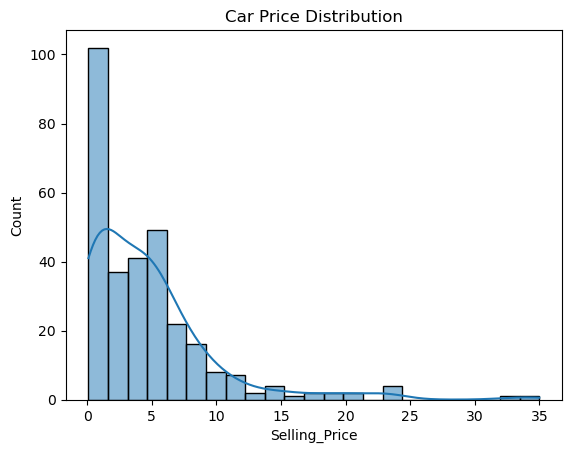

In [15]:
# Visualize the distribution of car prices
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Car Price Distribution")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

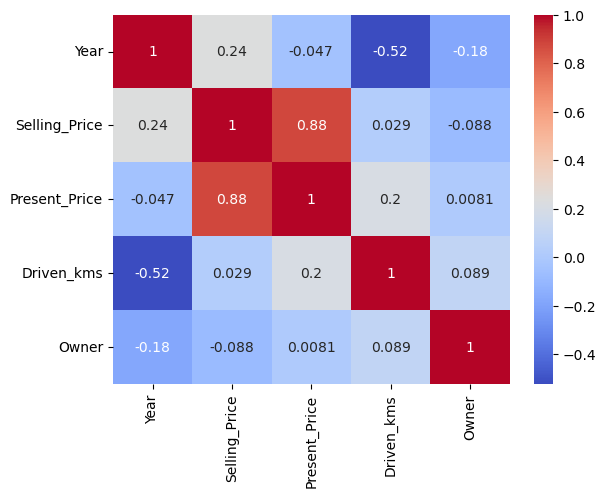

In [16]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

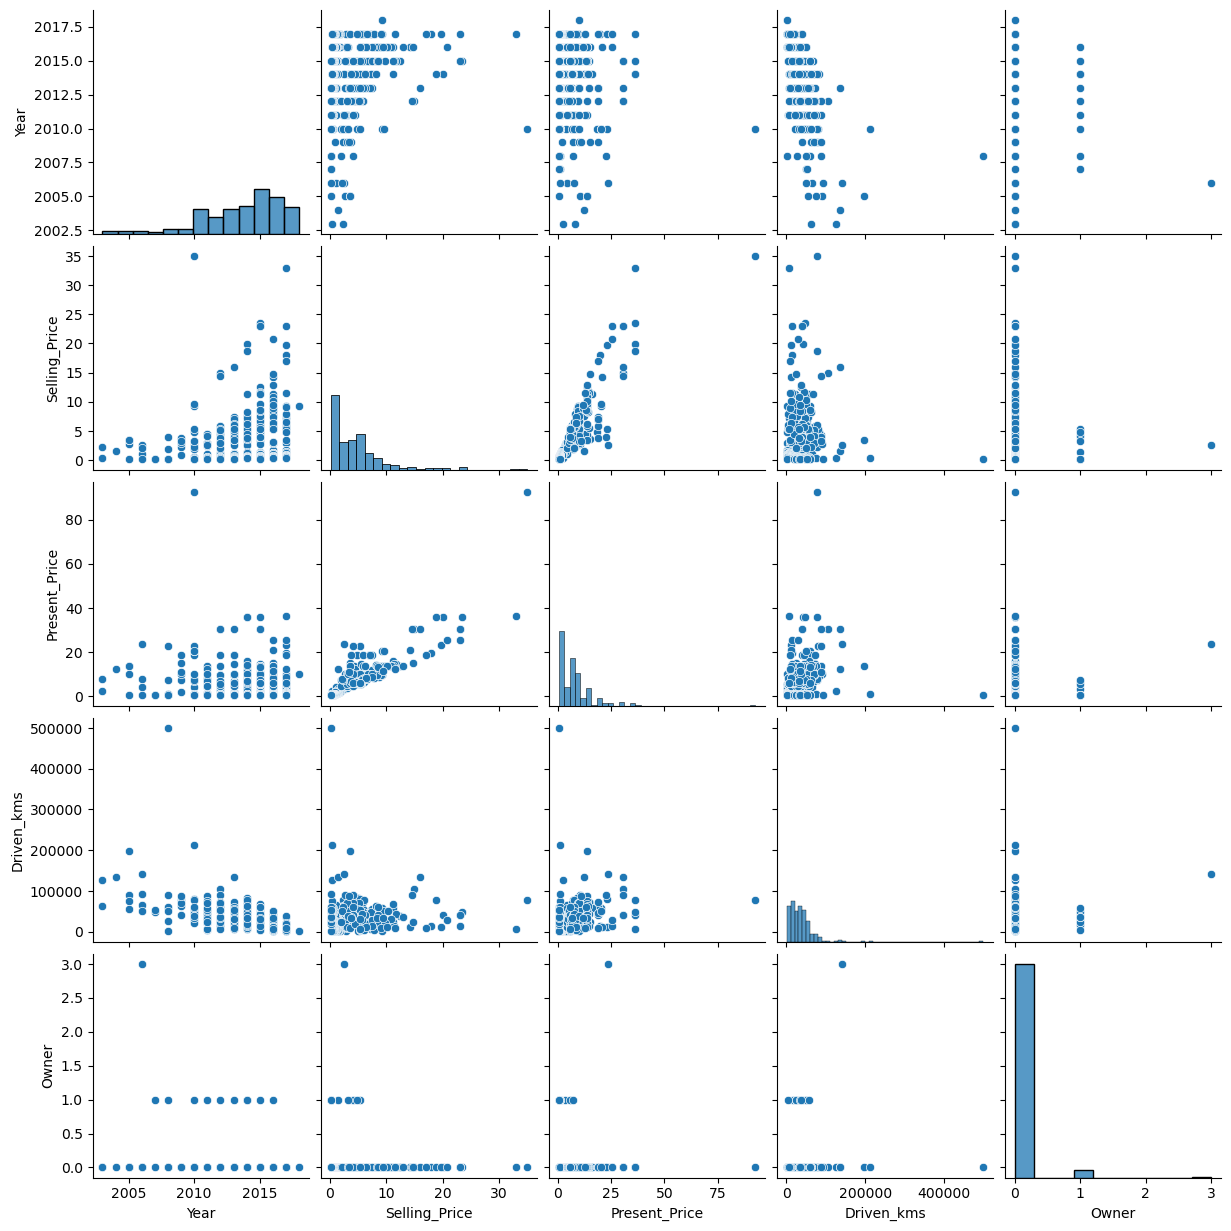

In [17]:
sns.pairplot(df)
plt.show

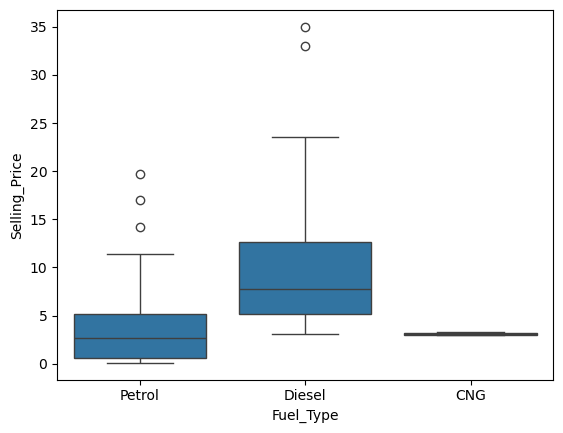

In [18]:
# Box Plot
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title=('Selling Price by Fuel type')
plt.show()

In [19]:
#Handle the mising values
df.dropna()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [20]:
# Convert categorical columns to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

In [21]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [22]:
# Feature scaling (standardization)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Driven_kms']] = scaler.fit_transform(df[['Driven_kms']])


In [23]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 240
Testing samples: 61


In [24]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model performance
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 9.221090393075883
R-squared: 0.5997023481234546


In [25]:
import pickle

# Save the model as a pickle file
with open('car_model.pkl', 'wb') as f:
    pickle.dump(model, f)
